<a href="https://colab.research.google.com/github/ElvinaShukurova/Telecom/blob/main/Lab9_Shukurova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2026-05-05 12:47:19--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2026-05-05 12:47:19--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2026-05-05 12:47:19 (4.33 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [5]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thinkdsp import *

# Упражнение 9.1

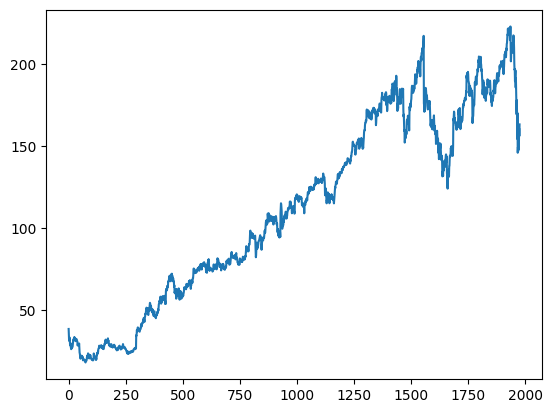

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thinkdsp import *

df = pd.read_csv('FB_2.csv', header=0, parse_dates=[0])
ys = df['Close'].values
if len(ys) % 2:
  ys = ys[:-1]
in_wave = Wave(ys, framerate=1)
in_wave.plot()

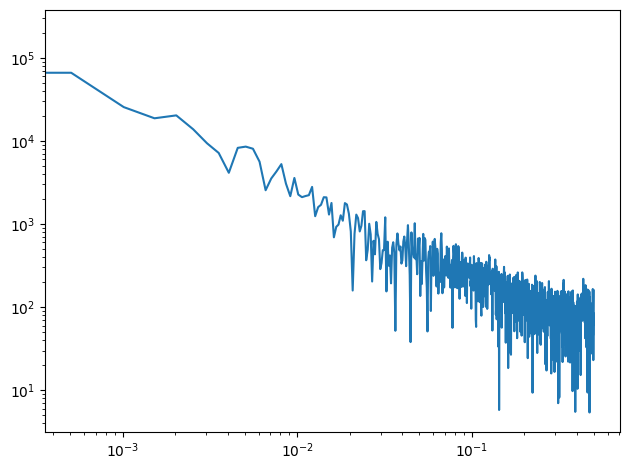

In [ ]:
in_spectrum = in_wave.make_spectrum()
in_spectrum.plot()
decorate(xscale='log', yscale='log')

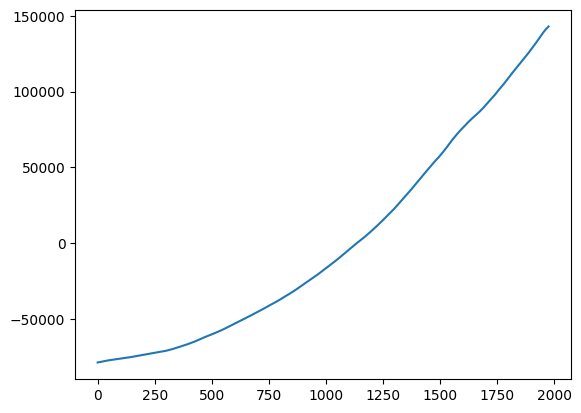

In [ ]:
out_wave = in_wave.cumsum()
out_wave.unbias()
out_wave.plot()

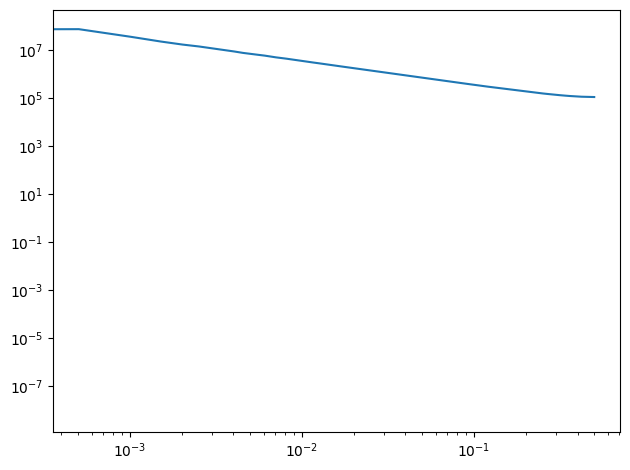

In [ ]:
out_spectrum = out_wave.make_spectrum()
out_spectrum.plot()
decorate(xscale='log', yscale='log')

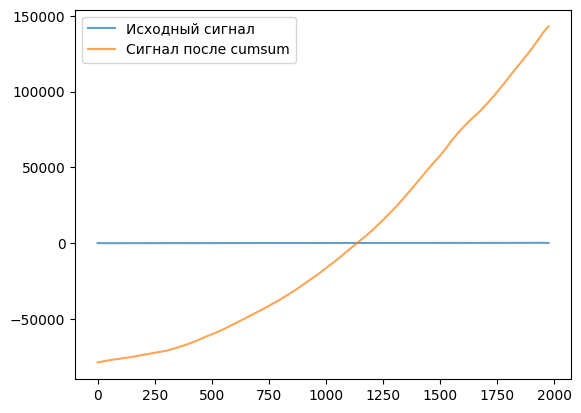

In [ ]:
in_wave.plot(label='Исходный сигнал', alpha=0.7)
out_wave.plot(label='Сигнал после cumsum', alpha=0.7)
plt.legend()

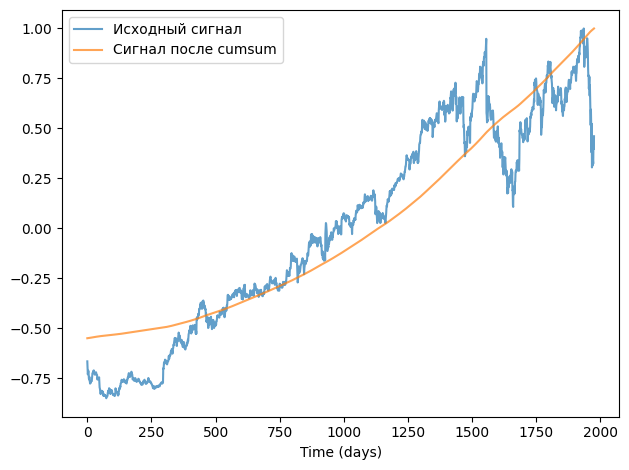

In [ ]:
in_norm = in_wave.copy()
in_norm.unbias()
in_norm.normalize()
out_norm = out_wave.copy()
out_norm.unbias()
out_norm.normalize()
in_norm.plot(label='Исходный сигнал', alpha=0.7)
out_norm.plot(label='Сигнал после cumsum', alpha=0.7)
decorate(xlabel='Time (days)')
plt.legend()

При замене пилообразного периодического сигнала на непериодические данные результат изменился. Для пилообразного сигнала cumsum даёт регулярную
периодическую кривую, а для реальных цен Facebook получается непериодический сглаженный тренд. Нарастающая сумма усиливает медленные изменения и уменьшает влияние быстрых колебаний

# Упражнение 9.2

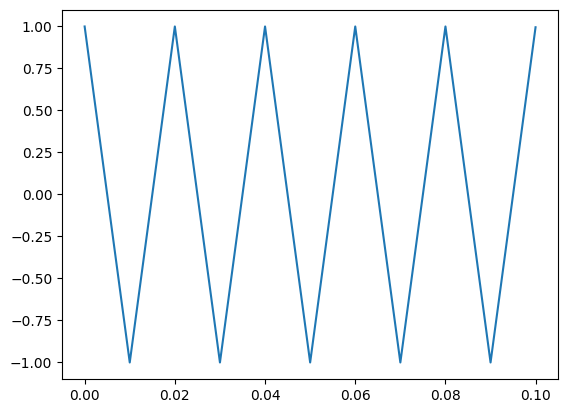

In [ ]:
from thinkdsp import TriangleSignal
signal = TriangleSignal(freq=50)
wave = signal.make_wave(duration=0.1, framerate=44100)
wave.unbias()
wave.normalize()
wave.plot()

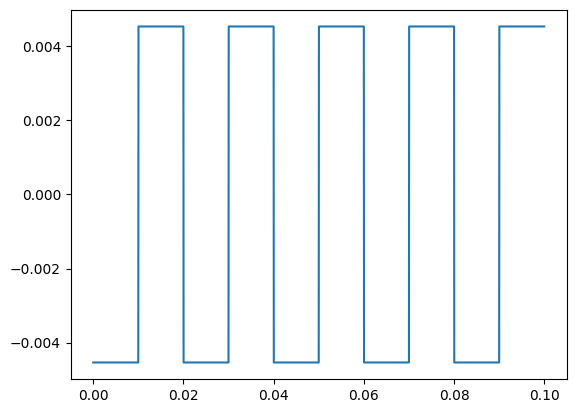

In [ ]:
out_wave = in_wave.diff()
out_wave.plot()

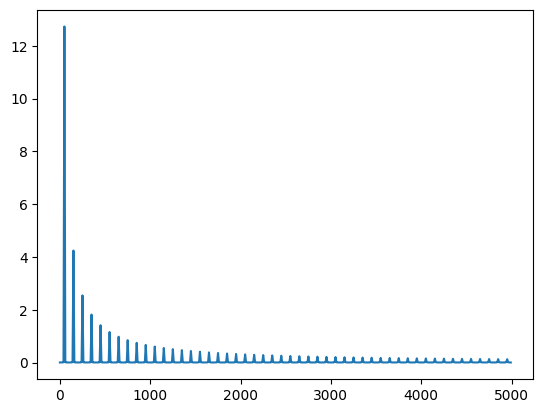

In [ ]:
# построение спектра diff
diff_spectrum = out_wave.make_spectrum()
diff_spectrum.plot(high=5000)

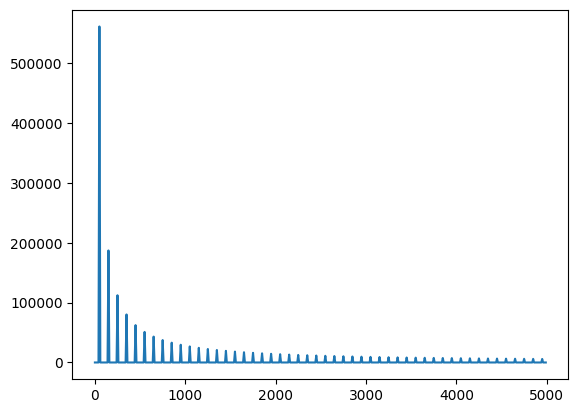

In [ ]:
spectrum = wave.make_spectrum()
deriv_spectrum = spectrum.differentiate()
deriv_spectrum.plot(high=5000)

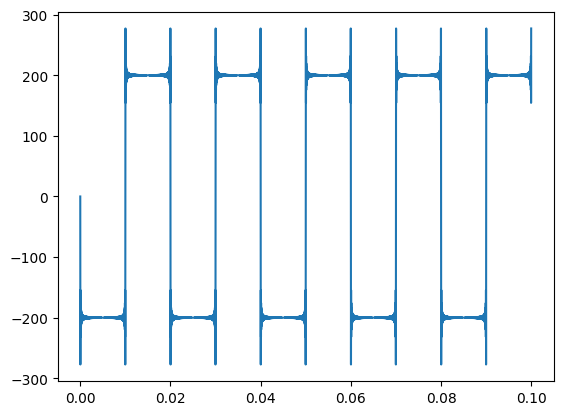

In [ ]:
out_wave2 = in_wave.make_spectrum().differentiate().make_wave()
out_wave2.plot()

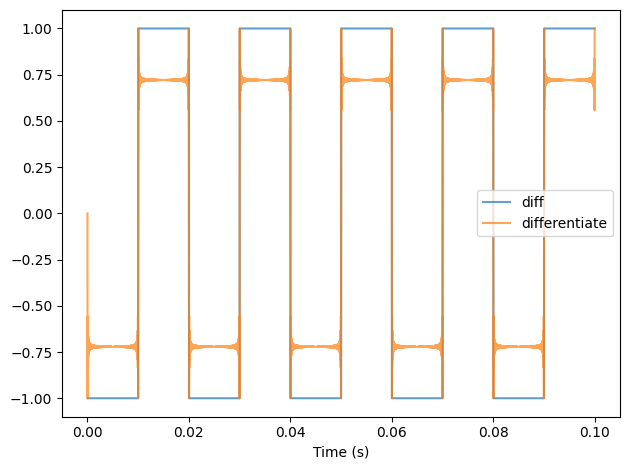

In [ ]:
out_wave.normalize()
out_wave2.normalize()
out_wave.plot(label='diff', alpha=0.7)
out_wave2.plot(label='differentiate', alpha=0.7)
decorate(xlabel='Time (s)')
plt.legend()

После нормализации видно, что операции diff и differentiate формируют похожую форму сигнала, напоминающую прямоугольную. При спектральном дифференцировании возникают колебания возле точек, где производная испытывает разрывы. В то же время оператор diff даёт более сглаженный результат.

# Упражнение 9.3

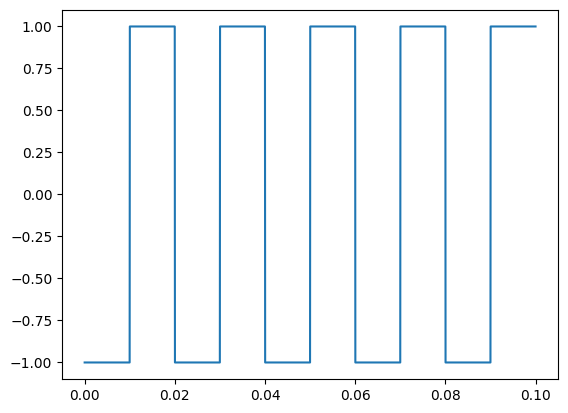

In [6]:
signal = SquareSignal(freq=50)
wave = signal.make_wave(duration=0.1, framerate=44100)
wave.unbias()
wave.normalize()
wave.plot()

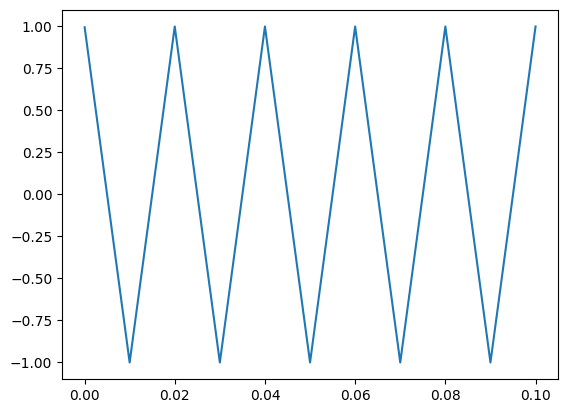

In [7]:
cumsum_wave = wave.cumsum()
cumsum_wave.unbias()
cumsum_wave.normalize()
cumsum_wave.plot()

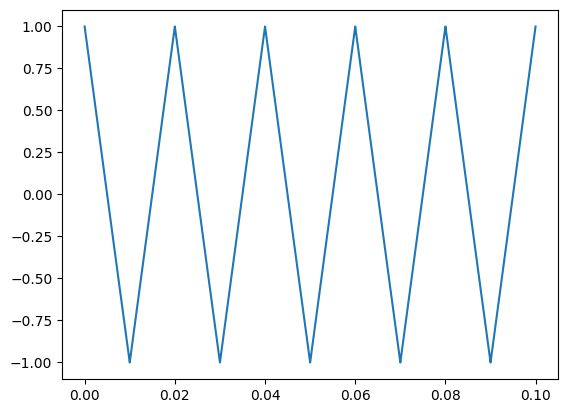

In [8]:
spectrum = wave.make_spectrum()
integ_spectrum = spectrum.integrate()
integ_spectrum.hs[0] = 0
integ_wave = integ_spectrum.make_wave()
integ_wave.unbias()
integ_wave.normalize()
integ_wave.plot()

При применении операции cumsum к прямоугольному сигналу получается треугольная форма. Спектральное интегрирование с использованием integrate даёт почти такой же результат. Это совпадение связано с тем, что исходный сигнал является периодическим и не содержит постоянной составляющей. Поэтому для такого сигнала оба метода интегрирования дают одинаковый эффект.

# Упражнение 9.4

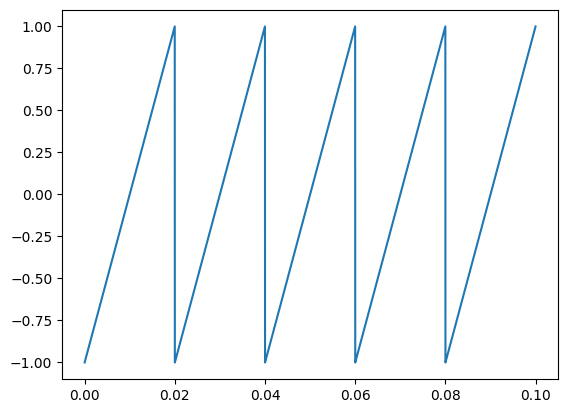

In [17]:
signal = SawtoothSignal(freq=50)
wave = signal.make_wave(duration=0.1, framerate=44100)
wave.unbias()
wave.normalize()
wave.plot()

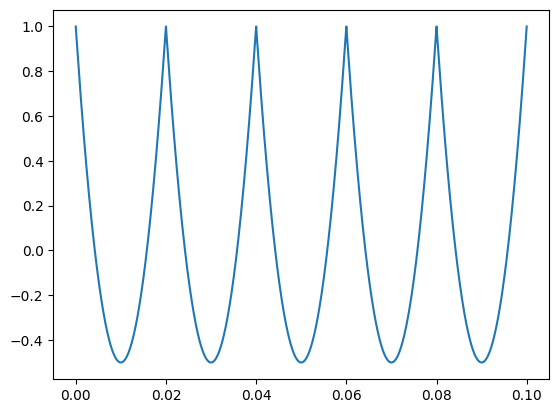

In [19]:
spectrum1 = spectrum.integrate()
spectrum1.hs[0] = 0
wave1 = spectrum1.make_wave()
wave1.unbias()
wave1.normalize()
wave1.plot()

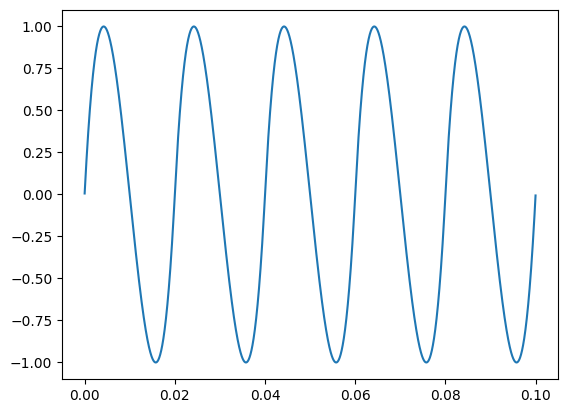

In [20]:
spectrum2 = spectrum1.integrate()
spectrum2.hs[0] = 0
wave2 = spectrum2.make_wave()
wave2.unbias()
wave2.normalize()
wave2.plot()

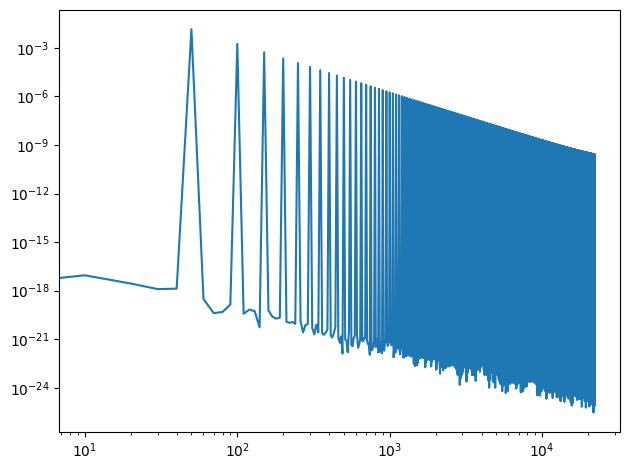

In [24]:
spectrum2.plot()
decorate(xscale='log', yscale='log')

После двукратного интегрирования сигнал значительно сглаживается: резкие скачки пилообразной формы исчезают. В результате он начинает напоминать синусоиду, поскольку интегрирование в частотной области делит амплитуды гармоник на их частоту, тем самым ослабляя высокочастотные компоненты. При повторном интегрировании этот эффект усиливается, и в сигнале в основном остаётся лишь первая (основная) гармоника.

# Упражнение 9.5

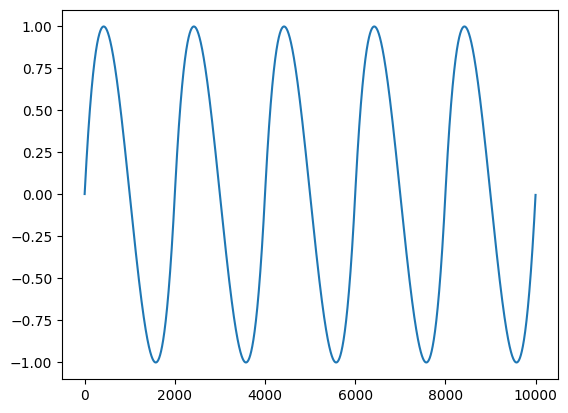

In [10]:
from thinkdsp import CubicSignal

in_wave = CubicSignal(freq=0.0005).make_wave(duration=10000, framerate=1)
in_wave.plot()

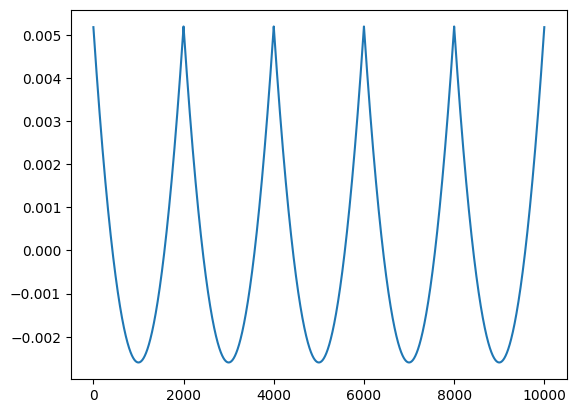

In [11]:
out_wave = in_wave.diff()
out_wave.plot()

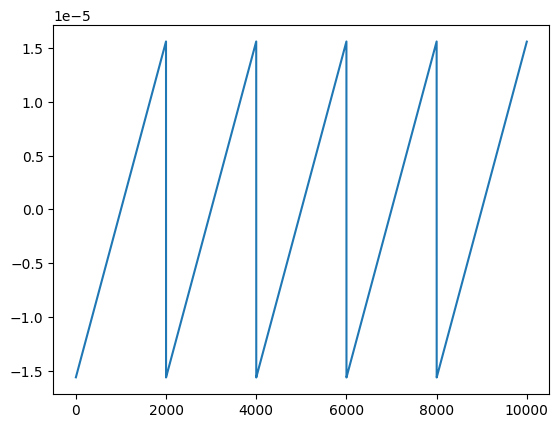

In [12]:
out_wave = out_wave.diff()
out_wave.plot()

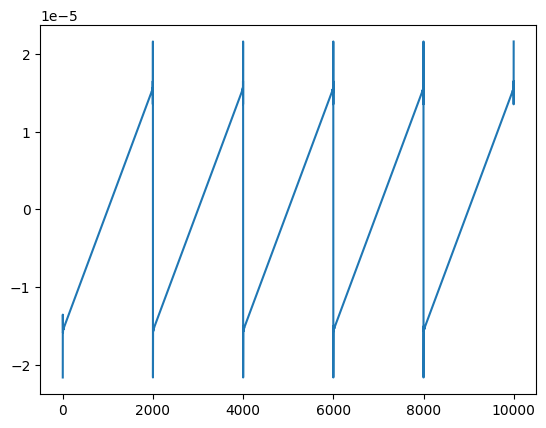

In [13]:
spectrum = in_wave.make_spectrum().differentiate().differentiate()
out_wave2 = spectrum.make_wave()
out_wave2.plot()

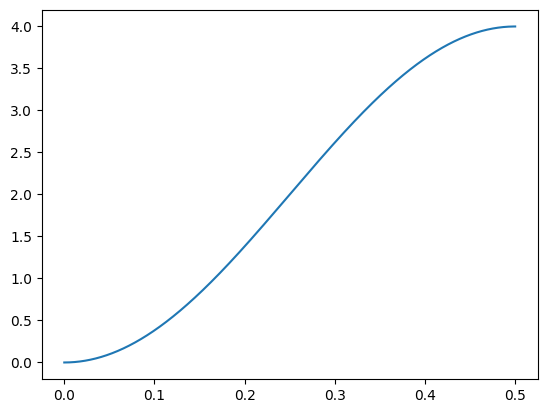

In [14]:
from thinkdsp import zero_pad
from thinkdsp import Wave

diff_window = np.array([-1.0, 2.0, -1.0])
padded = zero_pad(diff_window, len(in_wave))
diff_wave = Wave(padded, framerate=in_wave.framerate)
diff_filter = diff_wave.make_spectrum()
diff_filter.plot()

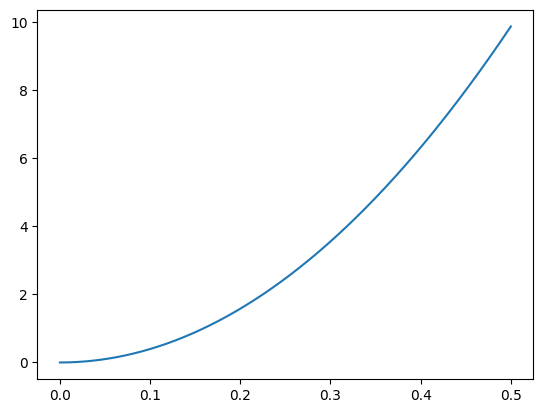

In [15]:
PI2 = np.pi * 2

deriv_filter = in_wave.make_spectrum()
deriv_filter.hs = (PI2 * 1j * deriv_filter.fs)**2
deriv_filter.plot()

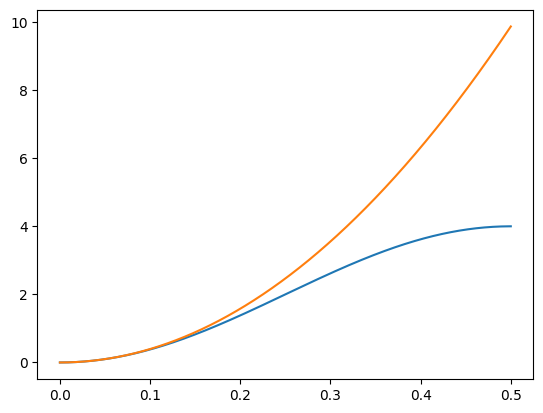

In [25]:
diff_filter.plot(label='2nd diff')
deriv_filter.plot(label='2nd deriv')

Оба являются фильтрами верхних частот, которые усиливают самые высокочастотные компоненты. Вторая производная имеет параболический характер, поэтому сильнее всего усиливает высокие частоты. Вторая разность хорошо приближает вторую производную только на низких частотах, а затем значительно от неё отклоняется.